# Tension Board 2 Mirror: Predictive Modelling

With the feature matrix built in notebook 04, we now turn to the central modelling question: how accurately can we predict climb difficulty from engineered features?

## Modelling Approach

We fit and compare several regression models on the hold-out test set:

1. **Linear models**  
   Linear Regression, Ridge, and Lasso serve as interpretable baselines. Coefficients reveal which features the model relies on most.

2. **Tree-based models**  
   Random Forest is the primary workhorse. It handles nonlinear relationships naturally and provides feature importance scores. A tuned variant with deeper trees and more estimators serves as the final classical model.

3. **Gradient Boosting**  
   We compare Gradient Boosting against Random Forest to assess whether boosting yields improved predictive performance over bagging.

## Evaluation Framework

We evaluate models on two levels:

- **Fine-grained difficulty scores**  
  The raw `display_difficulty` values. Accuracy within ±1 or ±2 points.

- **Grouped V-grades**  
  Fine-grained scores are mapped to V-grade buckets. This is the more practical metric: being off by half a grade is usually acceptable, while being off by two full grades is not.

## Output

The final products are trained models saved as joblib files, test set predictions for ensemble comparison in notebook 06, and a summary of model performance across all metrics.

## Notebook Structure

1. [Setup and Imports](#setup-and-imports)
2. [Load Feature Data](#load-feature-data)
3. [Training/Test Split](#training/test-split)
4. [Regression](#regression)
5. [Random Forest](#random-forest)
6. [Comparing Models](#comparing-models)
7. [Saving Models](#saving-models)
8. [Conclusion](#conclusion)

# Setup and Imports

In [1]:
"""
==================================
Setup and Imports
==================================
"""

# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform

import sqlite3

import re
import os
from collections import defaultdict

import ast

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

from PIL import Image

# Set some display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style
palette=['steelblue', 'coral', 'seagreen']  #(for multi-bar graphs)

# Set board image for some visual analysis
board_img = Image.open('../images/tb2_board_12x12_composite.png')

# Connect to the database
DB_PATH="../data/tb2.db"
conn = sqlite3.connect(DB_PATH)

# Set random state
RANDOM_STATE=3

In [2]:
"""
==================================
Query our data from the DB
==================================

This time we restrict to where `layout_id=10` for the TB2 Mirror.
We will also restrict ourselves to an angle of at most 50, since according to our grade vs angle distribution in notebook 01, things start to look a bit weird past 50.
(Probably a bias towards climbers who can actually climb that steep). We will encode this directly into our query.
"""

# Query climbs data
climbs_query = """
SELECT
    c.uuid,
    c.name AS climb_name,
    c.setter_username,
    c.layout_id AS layout_id,
    c.description,
    c.is_nomatch,
    c.is_listed,
    l.name AS layout_name,
    p.name AS board_name,
    c.frames,
    cs.angle,
    cs.display_difficulty,
    dg.boulder_name AS boulder_grade,
    cs.ascensionist_count,
    cs.quality_average,
    cs.fa_at
    
FROM climbs c
JOIN layouts l ON c.layout_id = l.id
JOIN products p ON l.product_id = p.id
JOIN climb_stats cs ON c.uuid = cs.climb_uuid
JOIN difficulty_grades dg ON ROUND(cs.display_difficulty) = dg.difficulty
WHERE cs.display_difficulty IS NOT NULL AND c.is_listed=1 AND c.layout_id=10 AND cs.angle <= 50
"""

# Query information about placements (and their mirrors)
placements_query = """
SELECT
    p.id AS placement_id,
    h.x,
    h.y,
    p.default_placement_role_id AS default_role_id,
    p.set_id AS set_id,
    s.name AS set_name,
    p_mirror.id AS mirror_placement_id
FROM placements p
JOIN holes h ON p.hole_id = h.id
JOIN sets s ON p.set_id = s.id
LEFT JOIN holes h_mirror ON h.mirrored_hole_id = h_mirror.id
LEFT JOIN placements p_mirror ON p_mirror.hole_id = h_mirror.id AND p_mirror.layout_id = p.layout_id
WHERE p.layout_id = 10
"""

# Load it into a DataFrame
df_climbs = pd.read_sql_query(climbs_query, conn)
df_placements = pd.read_sql_query(placements_query, conn)

df_hold_difficulty = pd.read_csv('../data/03_hold_difficulty/hold_difficulty_scores.csv', index_col='placement_id')
df_features = pd.read_csv('../data/04_climb_features/climb_features.csv', index_col='climb_uuid')

In [3]:
# Separate features and target
X = df_features.drop(columns=['display_difficulty'])
y = df_features['display_difficulty']

print(f"\nFeatures shape: {X.shape}")
print(f"Target range: {y.min():.1f} to {y.max():.1f}")
print(f"Target mean: {y.mean():.2f}")
print(f"Target std: {y.std():.2f}")

# Check for any remaining missing values
missing = X.isna().sum().sum()
print(f"\nMissing values in features: {missing}")

if missing > 0:
    print("Filling remaining missing values with column means...")
    X = X.fillna(X.mean())


Features shape: (42596, 48)
Target range: 10.0 to 32.0
Target mean: 19.83
Target std: 4.06

Missing values in features: 0


# Training/Test Split

In [4]:
"""
========================
Train/Test split
========================
"""

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Also create a scaled version for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled for linear models")

Training set: 34076 samples
Test set: 8520 samples

Features scaled for linear models


In [5]:
"""
===================================
Define evaluation functions
===================================
"""

grade_to_v = {
    10: 0, 11: 0, 12: 0,
    13: 1, 14: 1,
    15: 2,
    16: 3, 17: 3,
    18: 4, 19: 4,
    20: 5, 21: 5,
    22: 6,
    23: 7,
    24: 8, 25: 8,
    26: 9,
    27: 10,
    28: 11,
    29: 12,
    30: 13,
    31: 14,
    32: 15,
    33: 16,
}

def to_grouped_v(x):
    rounded = int(round(x))
    rounded = max(min(rounded, max(grade_to_v)), min(grade_to_v))
    return grade_to_v[rounded]

def grouped_v_metrics(y_true, y_pred):
    true_v = np.array([to_grouped_v(x) for x in y_true])
    pred_v = np.array([to_grouped_v(x) for x in y_pred])

    exact_grouped_v = np.mean(true_v == pred_v) * 100
    within_1_vgrade = np.mean(np.abs(true_v - pred_v) <= 1) * 100
    within_2_vgrades = np.mean(np.abs(true_v - pred_v) <= 2) * 100

    return {
        'exact_grouped_v': exact_grouped_v,
        'within_1_vgrade': within_1_vgrade,
        'within_2_vgrades': within_2_vgrades
    }

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Compute comprehensive evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Fine-grained difficulty accuracy
    within_1 = np.mean(np.abs(y_true - y_pred) <= 1) * 100
    within_2 = np.mean(np.abs(y_true - y_pred) <= 2) * 100

    # Grouped V-grade accuracy
    v_metrics = grouped_v_metrics(y_true, y_pred)

    # Print results
    print(f"### {model_name} Evaluation\n")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")
    print(f"\nAccuracy within ±1 grade: {within_1:.1f}%")
    print(f"Accuracy within ±2 grades: {within_2:.1f}%")
    print(f"\nExact grouped V-grade accuracy: {v_metrics['exact_grouped_v']:.1f}%")
    print(f"Accuracy within ±1 V-grade: {v_metrics['within_1_vgrade']:.1f}%")
    print(f"Accuracy within ±2 V-grades: {v_metrics['within_2_vgrades']:.1f}%")

    return {
        'model': model_name,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'within_1': within_1,
        'within_2': within_2,
        'exact_grouped_v': v_metrics['exact_grouped_v'],
        'within_1_vgrade': v_metrics['within_1_vgrade'],
        'within_2_vgrades': v_metrics['within_2_vgrades']
    }


def plot_predictions(y_true, y_pred, model_name="Model"):
    """
    Plot predicted vs actual values.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.3, s=20)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Grade', fontsize=12)
    ax.set_ylabel('Predicted Grade', fontsize=12)
    ax.set_title(f'{model_name}: Predicted vs Actual', fontsize=14)

    # Residuals
    ax = axes[1]
    residuals = y_pred - y_true
    ax.scatter(y_pred, residuals, alpha=0.3, s=20)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Grade', fontsize=12)
    ax.set_ylabel('Residual', fontsize=12)
    ax.set_title(f'{model_name}: Residual Plot', fontsize=14)

    plt.tight_layout()
    plt.show()


def plot_error_distribution(y_true, y_pred, model_name="Model"):
    """
    Plot error distribution.
    """
    errors = y_pred - y_true

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    ax = axes[0]
    ax.hist(errors, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', lw=2)
    ax.axvline(x=1, color='g', linestyle=':', lw=1)
    ax.axvline(x=-1, color='g', linestyle=':', lw=1)
    ax.set_xlabel('Prediction Error', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{model_name}: Error Distribution', fontsize=14)

    # Box plot by actual grade
    ax = axes[1]
    df_plot = pd.DataFrame({'actual': y_true, 'error': errors})
    df_plot.boxplot(column='error', by='actual', ax=ax)
    ax.set_xlabel('Actual Difficulty', fontsize=12)
    ax.set_ylabel('Prediction Error', fontsize=12)
    ax.set_title(f'{model_name}: Error by Grade', fontsize=14)
    plt.suptitle('')  # Remove automatic title

    plt.tight_layout()
    plt.show()


# Regression

## Linear Regression

In [6]:
"""
====================================
Linear Regression (baseline)
====================================
"""

print("=" * 60)
print("LINEAR REGRESSION")
print("=" * 60)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

# Evaluate
results_lr_train = evaluate_model(y_train, y_pred_lr_train, "Linear Regression (Train)")
print()
results_lr_test = evaluate_model(y_test, y_pred_lr_test, "Linear Regression (Test)")

# Store results
all_results = []
all_results.append({**results_lr_test, 'set': 'test'})

LINEAR REGRESSION
### Linear Regression (Train) Evaluation

MAE:  2.225
RMSE: 2.773
R²:   0.535

Accuracy within ±1 grade: 27.2%
Accuracy within ±2 grades: 51.9%

Exact grouped V-grade accuracy: 23.3%
Accuracy within ±1 V-grade: 60.2%
Accuracy within ±2 V-grades: 83.1%

### Linear Regression (Test) Evaluation

MAE:  2.191
RMSE: 2.742
R²:   0.537

Accuracy within ±1 grade: 28.1%
Accuracy within ±2 grades: 53.1%

Exact grouped V-grade accuracy: 23.9%
Accuracy within ±1 V-grade: 61.3%
Accuracy within ±2 V-grades: 83.5%


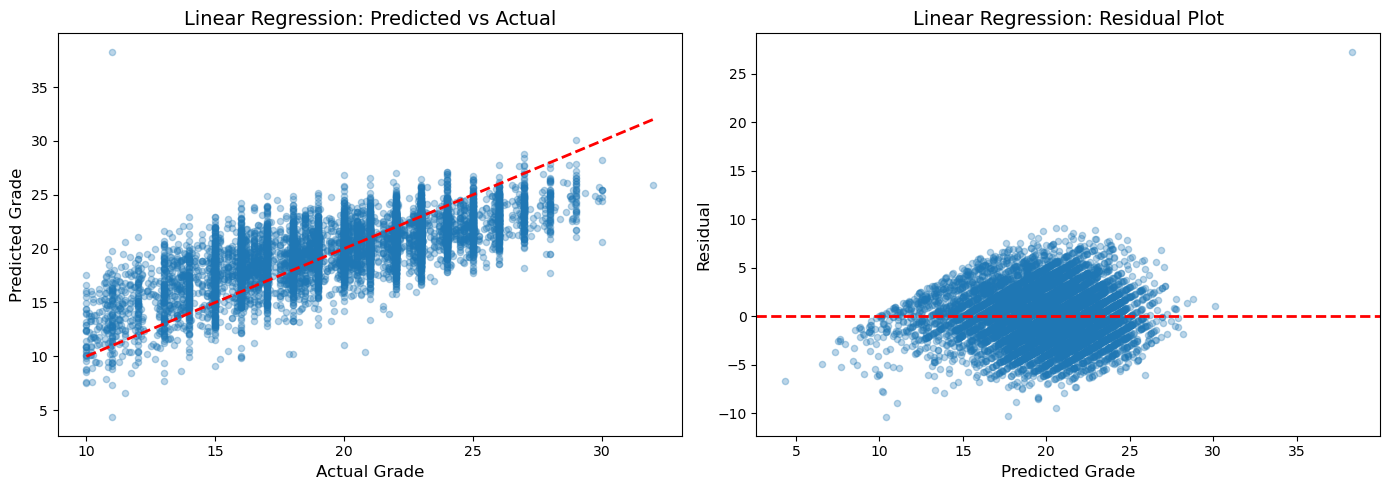

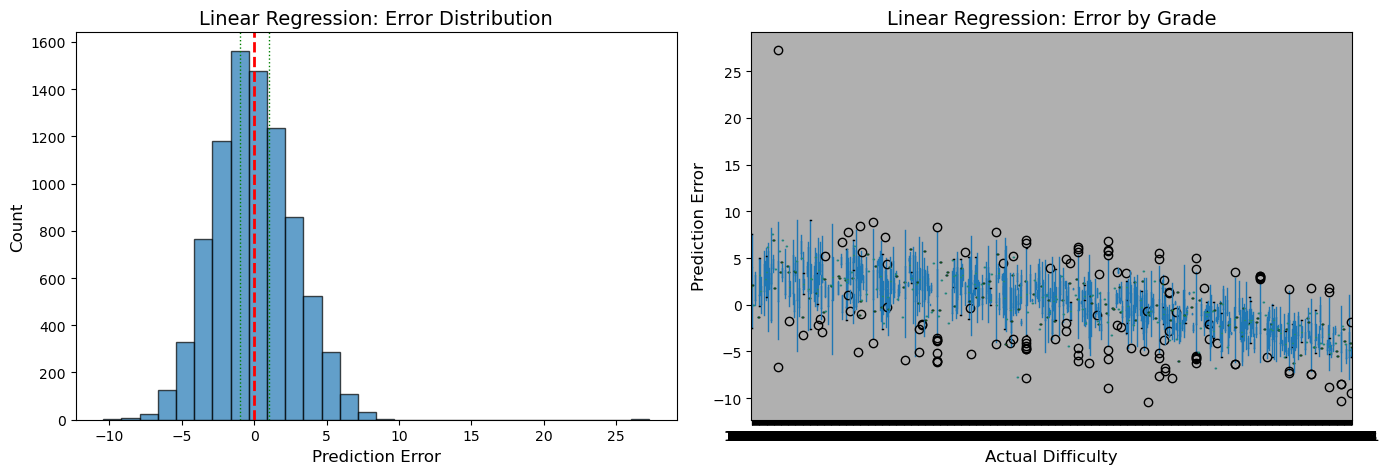

In [7]:
"""
====================================
Linear regression - visualization
====================================
"""

plot_predictions(y_test, y_pred_lr_test, "Linear Regression")
plot_error_distribution(y_test, y_pred_lr_test, "Linear Regression")

### Top 20 Most Important Coefficients (Linear Regression)



,feature,coefficient
24,mean_hand_reach,2.045725
0,angle,1.694429
46,complexity_score,1.374454
34,mean_pairwise_distance,-1.329399
10,std_x,1.296368
32,convex_hull_area,0.928098
25,max_hand_reach,-0.912426
28,hand_spread_y,0.729073
18,bbox_area,-0.680104
26,std_hand_reach,-0.520199


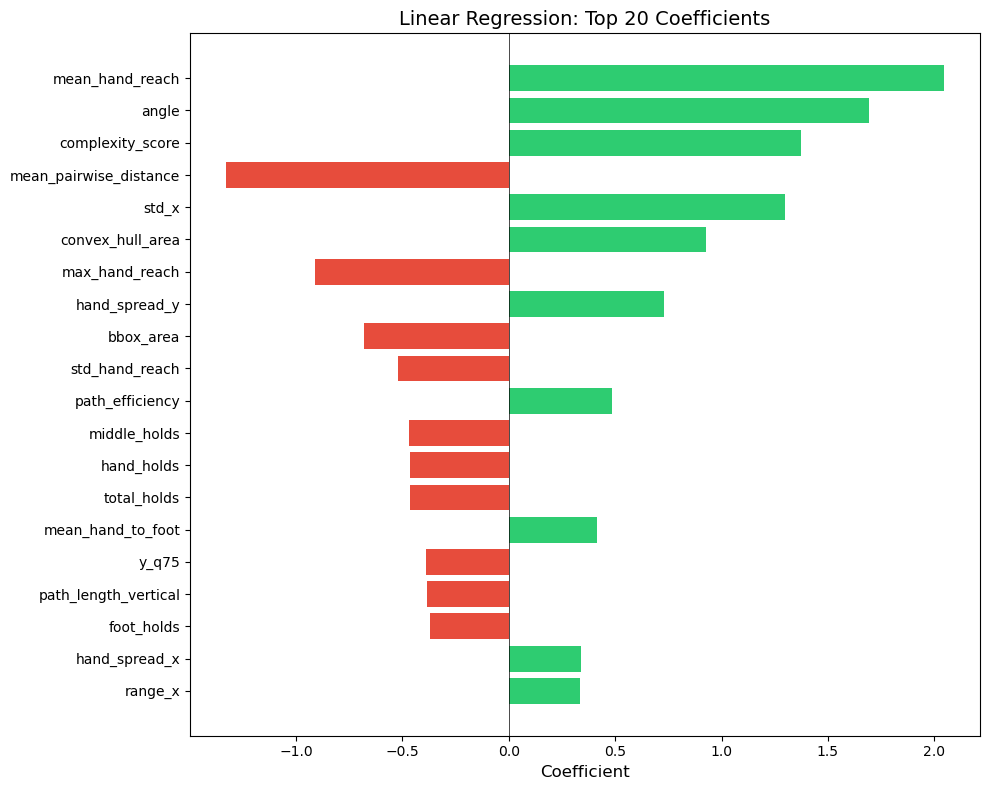

In [8]:
"""
====================================
Linear regression - coefficient analysis
====================================
"""

# Get coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("### Top 20 Most Important Coefficients (Linear Regression)\n")
display(coef_df.head(20))

# Plot top coefficients
fig, ax = plt.subplots(figsize=(10, 8))

top_coef = coef_df.head(20)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_coef['coefficient']]

ax.barh(range(len(top_coef)), top_coef['coefficient'], color=colors)
ax.set_yticks(range(len(top_coef)))
ax.set_yticklabels(top_coef['feature'])
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_title('Linear Regression: Top 20 Coefficients', fontsize=14)
ax.axvline(x=0, color='black', linestyle='-', lw=0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/linear_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Ridge Regression

In [9]:
"""
====================================
Ridge Regression
====================================
"""

print("=" * 60)
print("RIDGE REGRESSION")
print("=" * 60)

from sklearn.linear_model import RidgeCV

# Cross-validate for best alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge.alpha_}")

# Predict
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
results_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
all_results.append({**results_ridge, 'set': 'test'})

RIDGE REGRESSION
Best alpha: 0.01
### Ridge Regression Evaluation

MAE:  2.191
RMSE: 2.742
R²:   0.537

Accuracy within ±1 grade: 28.1%
Accuracy within ±2 grades: 53.1%

Exact grouped V-grade accuracy: 23.9%
Accuracy within ±1 V-grade: 61.3%
Accuracy within ±2 V-grades: 83.5%


## Lasso Regression

In [10]:
"""
====================================
Lasso Regression
====================================
"""

print("=" * 60)
print("LASSO REGRESSION")
print("=" * 60)

from sklearn.linear_model import LassoCV

# Cross-validate for best alpha
lasso = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.4f}")

# Count non-zero coefficients
non_zero = np.sum(lasso.coef_ != 0)
print(f"Non-zero coefficients: {non_zero} / {len(lasso.coef_)}")

# Predict
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate
results_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")
all_results.append({**results_lasso, 'set': 'test'})

# Show features selected by Lasso
lasso_features = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
})
lasso_features = lasso_features[lasso_features['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)

print(f"\n### Features Selected by Lasso ({len(lasso_features)})\n")
display(lasso_features)

LASSO REGRESSION
Best alpha: 0.0022
Non-zero coefficients: 40 / 48
### Lasso Regression Evaluation

MAE:  2.192
RMSE: 2.741
R²:   0.538

Accuracy within ±1 grade: 27.9%
Accuracy within ±2 grades: 53.1%

Exact grouped V-grade accuracy: 23.8%
Accuracy within ±1 V-grade: 61.3%
Accuracy within ±2 V-grades: 83.5%

### Features Selected by Lasso (40)



,feature,coefficient
24,mean_hand_reach,1.958970
0,angle,1.600089
46,complexity_score,1.297888
2,total_holds,-1.051692
10,std_x,0.967384
25,max_hand_reach,-0.899914
34,mean_pairwise_distance,-0.853615
32,convex_hull_area,0.761673
28,hand_spread_y,0.705660
7,middle_holds,-0.503301


# Random Forest

In [11]:
"""
====================================
Random Forest - Base Model
====================================
"""

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Base random forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

# Evaluate
results_rf_train = evaluate_model(y_train, y_pred_rf_train, "Random Forest (Train)")
print()
results_rf_test = evaluate_model(y_test, y_pred_rf_test, "Random Forest (Test)")
all_results.append({**results_rf_test, 'set': 'test'})

RANDOM FOREST
### Random Forest (Train) Evaluation

MAE:  0.670
RMSE: 0.867
R²:   0.955

Accuracy within ±1 grade: 77.1%
Accuracy within ±2 grades: 97.2%

Exact grouped V-grade accuracy: 61.7%
Accuracy within ±1 V-grade: 97.0%
Accuracy within ±2 V-grades: 99.9%

### Random Forest (Test) Evaluation

MAE:  1.774
RMSE: 2.284
R²:   0.679

Accuracy within ±1 grade: 36.8%
Accuracy within ±2 grades: 64.4%

Exact grouped V-grade accuracy: 30.5%
Accuracy within ±1 V-grade: 71.3%
Accuracy within ±2 V-grades: 89.5%


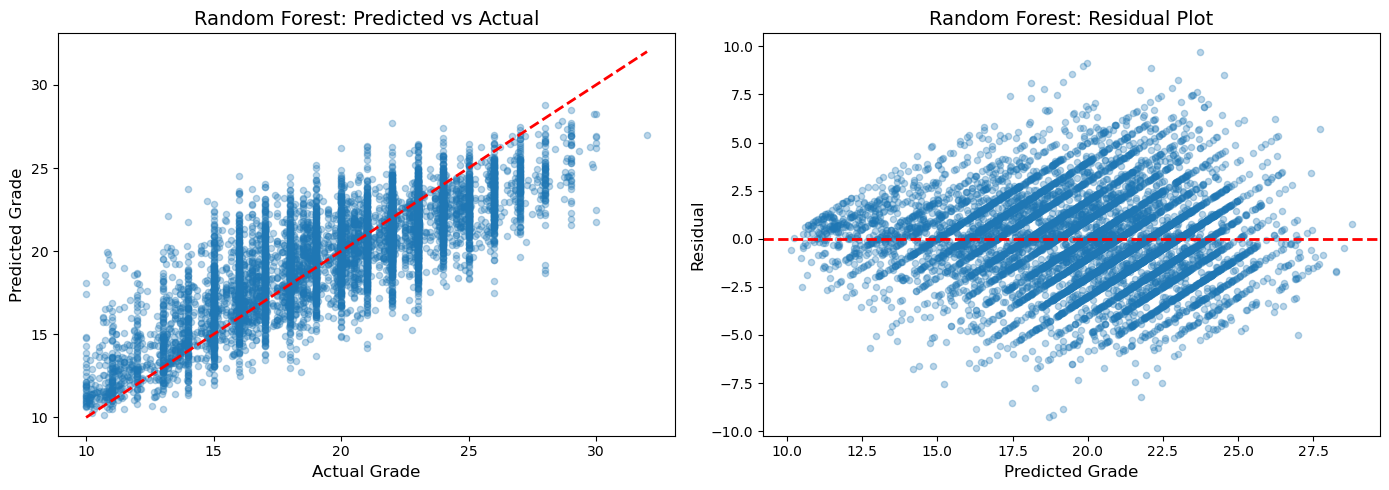

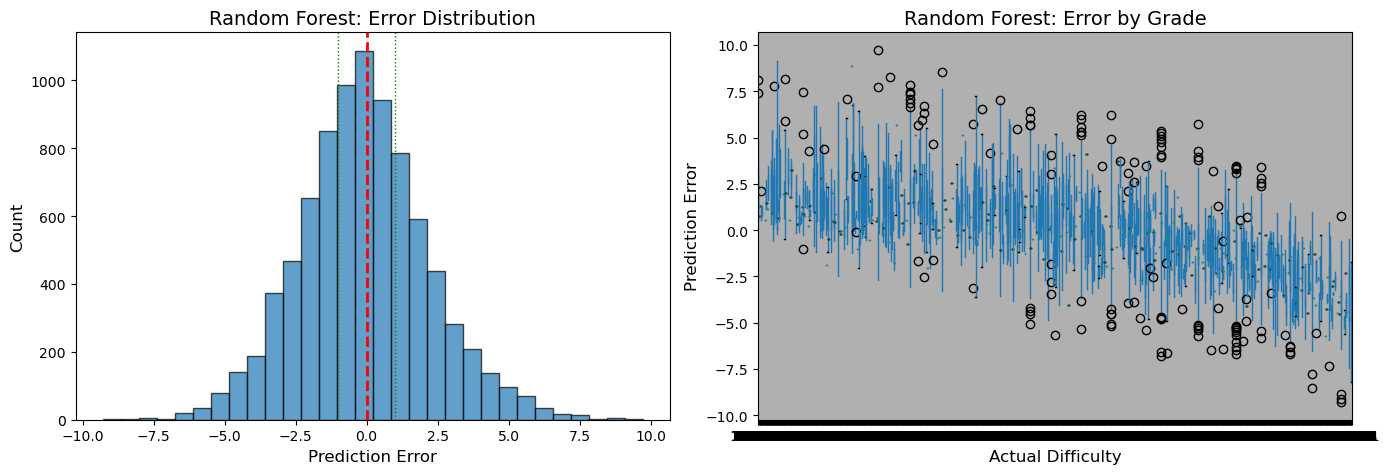

In [12]:
"""
====================================
Random Forest - Visualization
====================================
"""

plot_predictions(y_test, y_pred_rf_test, "Random Forest")
plot_error_distribution(y_test, y_pred_rf_test, "Random Forest")

### Top 20 Most Important Features (Random Forest)



,feature,importance
19,hold_density,0.269487
24,mean_hand_reach,0.119835
0,angle,0.077951
1,angle_squared,0.067107
26,std_hand_reach,0.024337
14,min_y,0.024004
46,complexity_score,0.021372
33,hull_area_to_bbox_ratio,0.020149
41,mean_y_relative_to_start,0.019535
31,std_hand_to_foot,0.016270


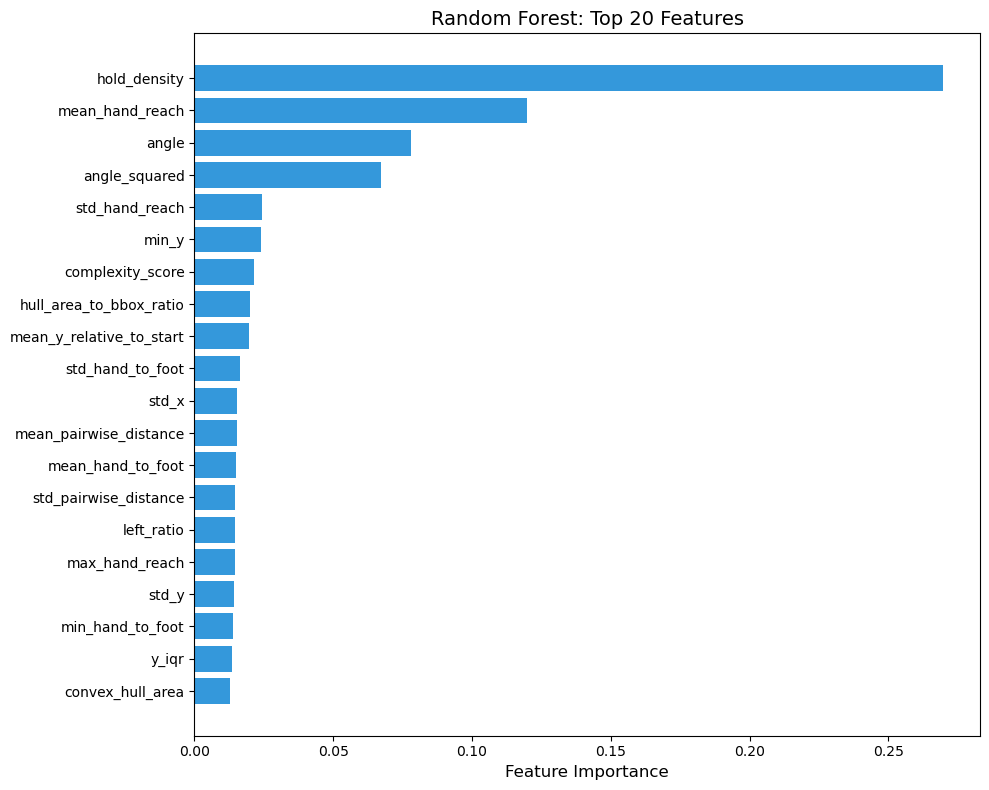

In [13]:
"""
====================================
RF - Feature Importance
====================================
"""

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("### Top 20 Most Important Features (Random Forest)\n")
display(importance_df.head(20))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

top_features = importance_df.head(20)
ax.barh(range(len(top_features)), top_features['importance'], color='#3498db')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest: Top 20 Features', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/random_forest_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
"""
====================================
RF - Skip tuning, use good defaults
====================================
"""

print("Using pre-tuned Random Forest parameters...\n")

rf_best = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

results_rf_tuned = evaluate_model(y_test, y_pred_rf_best, "Random Forest (Tuned)")
all_results.append({**results_rf_tuned, 'set': 'test'})

# Save tuned Random Forest test predictions for downstream comparison
os.makedirs('../data/06_deep_learning', exist_ok=True)
os.makedirs('../models', exist_ok=True)

np.save('../data/06_deep_learning/rf_test_predictions.npy', y_pred_rf_best)
np.save('../data/06_deep_learning/rf_test_actuals.npy', y_test.values)

rf_eval_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred_rf_best
})
rf_eval_df.to_csv('../models/random_forest_test_eval.csv', index=False)

print("\nSaved Random Forest test predictions for Notebook 06 comparison.")


Using pre-tuned Random Forest parameters...

### Random Forest (Tuned) Evaluation

MAE:  1.788
RMSE: 2.293
R²:   0.676

Accuracy within ±1 grade: 36.1%
Accuracy within ±2 grades: 64.3%

Exact grouped V-grade accuracy: 30.2%
Accuracy within ±1 V-grade: 70.8%
Accuracy within ±2 V-grades: 89.4%

Saved Random Forest test predictions for Notebook 06 comparison.


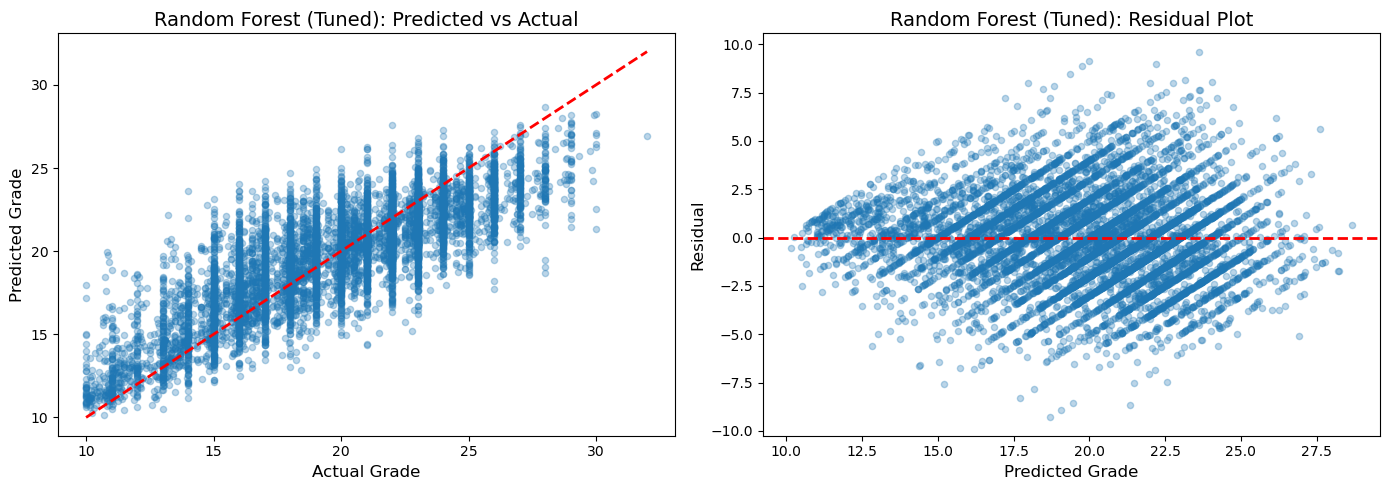

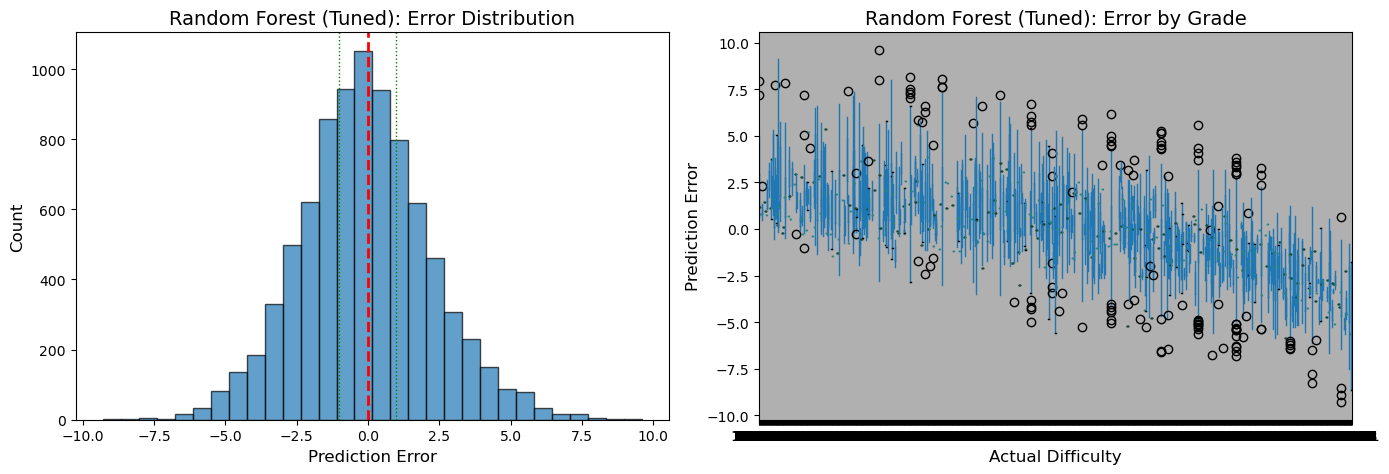

In [15]:
"""
====================================
RF Tuned - Visualization
====================================
"""

plot_predictions(y_test, y_pred_rf_best, "Random Forest (Tuned)")
plot_error_distribution(y_test, y_pred_rf_best, "Random Forest (Tuned)")

# Comparing models

CROSS-VALIDATION COMPARISON

Cross-validating Linear Regression...

Cross-validating Ridge Regression...

Cross-validating Lasso Regression...

Cross-validating Random Forest...

Cross-validating RF (Tuned)...

### Cross-Validation Results (5-Fold)



,model,cv_mae_mean,cv_mae_std
3,Random Forest,1.854317,0.018546
4,RF (Tuned),1.859828,0.017931
0,Linear Regression,2.228513,0.020411
1,Ridge Regression,2.228513,0.020411
2,Lasso Regression,2.230571,0.021014


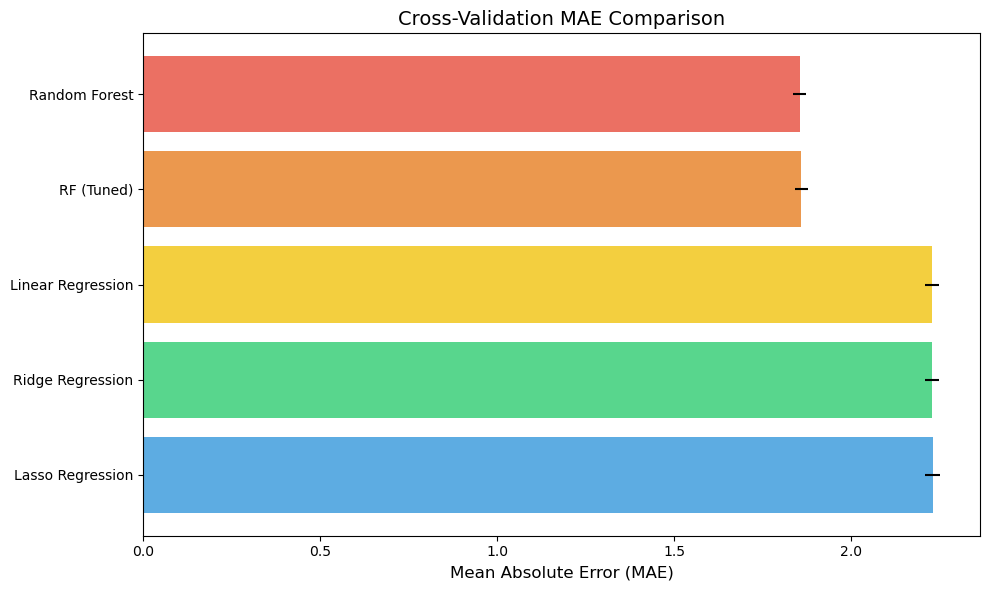

In [16]:
"""
====================================
Cross-Validation comparison
====================================
"""

print("=" * 60)
print("CROSS-VALIDATION COMPARISON")
print("=" * 60)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=ridge.alpha_),
    'Lasso Regression': Lasso(alpha=lasso.alpha_),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'RF (Tuned)': rf_best
}

cv_results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    print(f"\nCross-validating {name}...")
    
    if 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='neg_mean_absolute_error')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_error')
    
    cv_results.append({
        'model': name,
        'cv_mae_mean': -cv_scores.mean(),
        'cv_mae_std': cv_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('cv_mae_mean')

print("\n### Cross-Validation Results (5-Fold)\n")
display(cv_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(range(len(cv_df)), cv_df['cv_mae_mean'], xerr=cv_df['cv_mae_std'], 
        color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db'], alpha=0.8)
ax.set_yticks(range(len(cv_df)))
ax.set_yticklabels(cv_df['model'])
ax.set_xlabel('Mean Absolute Error (MAE)', fontsize=12)
ax.set_title('Cross-Validation MAE Comparison', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL COMPARISON SUMMARY

### Test Set Performance



,model,mae,rmse,r2,within_1,within_2
3,Random Forest (Test),1.773939,2.284492,0.678765,36.807512,64.389671
4,Random Forest (Tuned),1.787864,2.292637,0.676471,36.056338,64.307512
1,Ridge Regression,2.191489,2.742083,0.537188,28.051643,53.133803
0,Linear Regression (Test),2.191489,2.742083,0.537188,28.051643,53.133803
2,Lasso Regression,2.191844,2.740699,0.537655,27.934272,53.063380


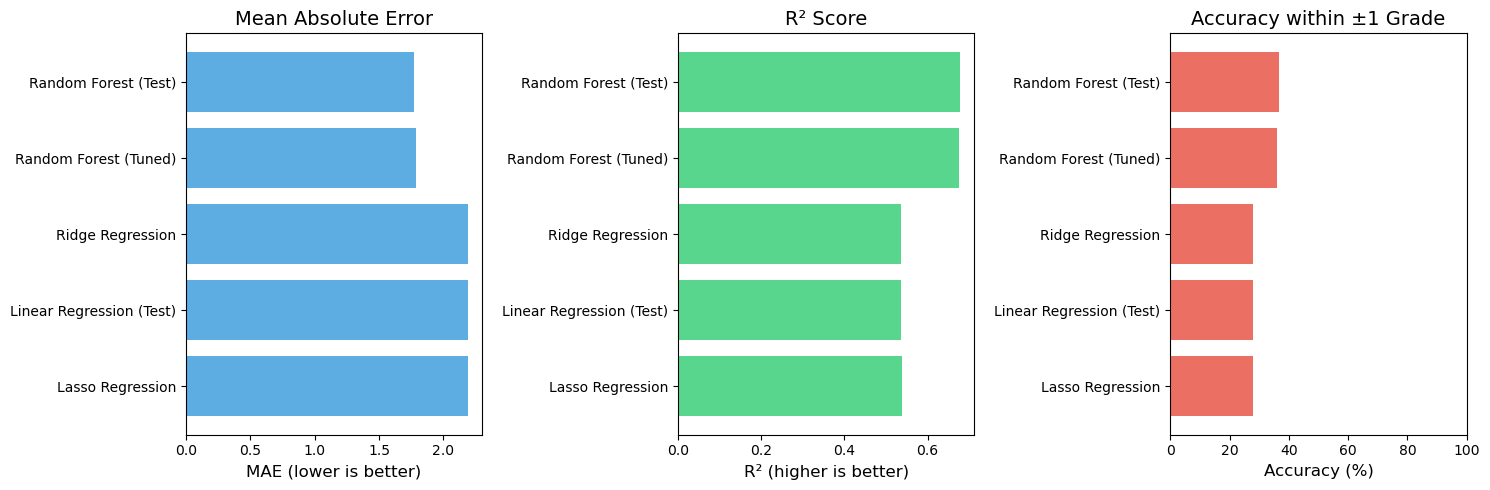

In [17]:
"""
====================================
Model Comparison Summary
====================================
"""

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('mae')

print("\n### Test Set Performance\n")
display(results_df[['model', 'mae', 'rmse', 'r2', 'within_1', 'within_2']])

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE comparison
ax = axes[0]
ax.barh(results_df['model'], results_df['mae'], color='#3498db', alpha=0.8)
ax.set_xlabel('MAE (lower is better)', fontsize=12)
ax.set_title('Mean Absolute Error', fontsize=14)
ax.invert_yaxis()

# R² comparison
ax = axes[1]
ax.barh(results_df['model'], results_df['r2'], color='#2ecc71', alpha=0.8)
ax.set_xlabel('R² (higher is better)', fontsize=12)
ax.set_title('R² Score', fontsize=14)
ax.invert_yaxis()

# Accuracy within ±1
ax = axes[2]
ax.barh(results_df['model'], results_df['within_1'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy within ±1 Grade', fontsize=14)
ax.invert_yaxis()
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
"""
====================================
Prediction Examples
====================================
"""

print("### Sample Predictions\n")

# Show some example predictions
sample_indices = np.random.choice(len(X_test), 10, replace=False)

examples = pd.DataFrame({
    'Actual': y_test.iloc[sample_indices].values,
    'Linear Reg': y_pred_lr_test[sample_indices],
    'Ridge': y_pred_ridge[sample_indices],
    'Random Forest': y_pred_rf_test[sample_indices],
    'RF (Tuned)': y_pred_rf_best[sample_indices]
}).round(2)

examples['Actual V'] = [to_grouped_v(x) for x in examples['Actual']]
examples['RF (Tuned) V'] = [to_grouped_v(x) for x in examples['RF (Tuned)']]
examples['Linear Error'] = (examples['Actual'] - examples['Linear Reg']).abs().round(2)
examples['RF Error'] = (examples['Actual'] - examples['RF (Tuned)']).abs().round(2)
examples['RF V-Miss'] = (examples['Actual V'] - examples['RF (Tuned) V']).abs()

display(examples)


### Sample Predictions



,Actual,Linear Reg,Ridge,Random Forest,RF (Tuned),Actual V,RF (Tuned) V,Linear Error,RF Error,RF V-Miss
0,24.86,19.22,19.22,19.75,19.70,8,5,5.64,5.16,3
1,22.06,21.57,21.57,22.26,21.98,6,6,0.49,0.08,0
2,24.78,22.18,22.18,22.71,22.65,8,7,2.60,2.13,1
3,27.69,24.52,24.52,24.96,24.72,11,8,3.17,2.97,3
4,23.00,20.00,20.00,21.09,21.06,7,5,3.00,1.94,2
5,21.00,18.47,18.47,19.31,19.43,5,4,2.53,1.57,1
6,16.25,18.53,18.53,17.98,18.11,3,4,2.28,1.86,1
7,22.00,22.21,22.21,22.57,22.60,6,7,0.21,0.60,1
8,22.00,21.90,21.90,22.55,22.59,6,7,0.10,0.59,1
9,16.00,16.32,16.32,17.50,17.50,3,4,0.32,1.50,1


### Error Analysis by Grade



,count,mae,bias,within_1
actual,,,,
10.0000,34,2.374,-2.374,20.588
10.0845,1,1.167,-1.167,0.000
10.1071,1,0.964,-0.964,100.000
10.1154,1,0.808,-0.808,100.000
10.1250,1,0.973,-0.973,100.000
...,...,...,...,...
29.8571,1,4.992,4.992,0.000
29.8750,1,5.630,5.630,0.000
29.9091,1,1.713,1.713,0.000


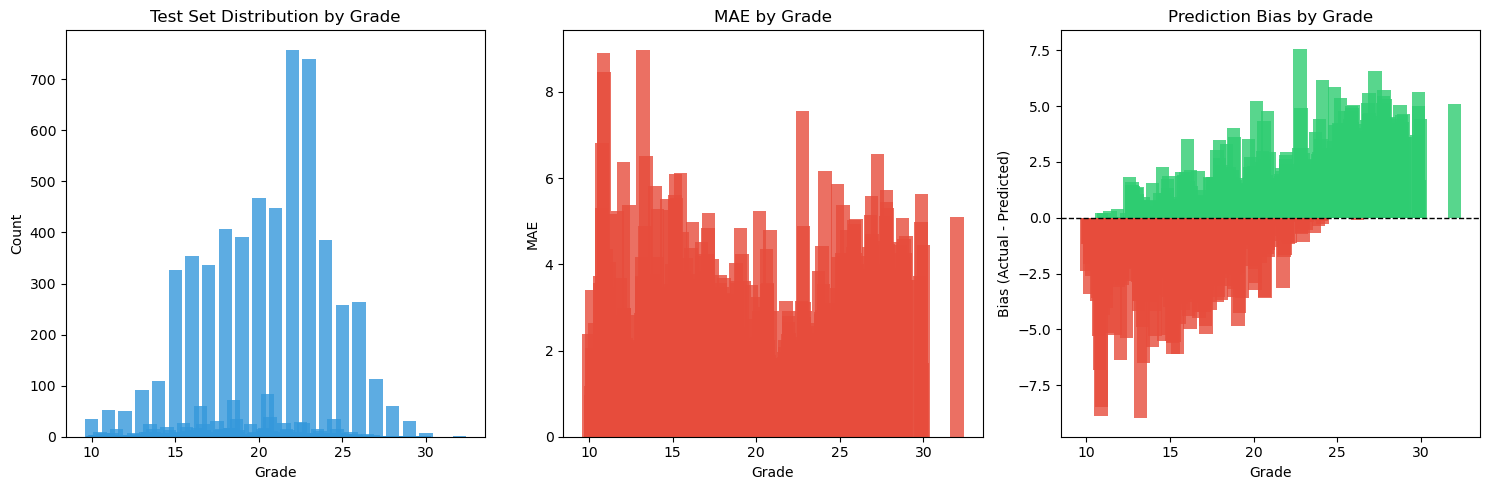

In [19]:
"""
====================================
Error analysis by grade
====================================
"""

print("### Error Analysis by Grade\n")

# Group by actual grade
df_analysis = pd.DataFrame({
    'actual': y_test,
    'predicted_rf': y_pred_rf_best,
    'error_rf': y_test - y_pred_rf_best
})

grade_analysis = df_analysis.groupby('actual').agg(
    count=('actual', 'count'),
    mae=('error_rf', lambda x: np.abs(x).mean()),
    bias=('error_rf', 'mean'),
    within_1=('error_rf', lambda x: (np.abs(x) <= 1).mean() * 100)
).round(3)

display(grade_analysis)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Count by grade
ax = axes[0]
ax.bar(grade_analysis.index, grade_analysis['count'], color='#3498db', alpha=0.8)
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
ax.set_title('Test Set Distribution by Grade')

# MAE by grade
ax = axes[1]
ax.bar(grade_analysis.index, grade_analysis['mae'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Grade')
ax.set_ylabel('MAE')
ax.set_title('MAE by Grade')

# Bias by grade
ax = axes[2]
colors = ['#2ecc71' if b >= 0 else '#e74c3c' for b in grade_analysis['bias']]
ax.bar(grade_analysis.index, grade_analysis['bias'], color=colors, alpha=0.8)
ax.set_xlabel('Grade')
ax.set_ylabel('Bias (Actual - Predicted)')
ax.set_title('Prediction Bias by Grade')
ax.axhline(y=0, color='black', linestyle='--', lw=1)

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/error_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

### Prediction Confidence Analysis

Correlation between prediction std and absolute error: 0.272


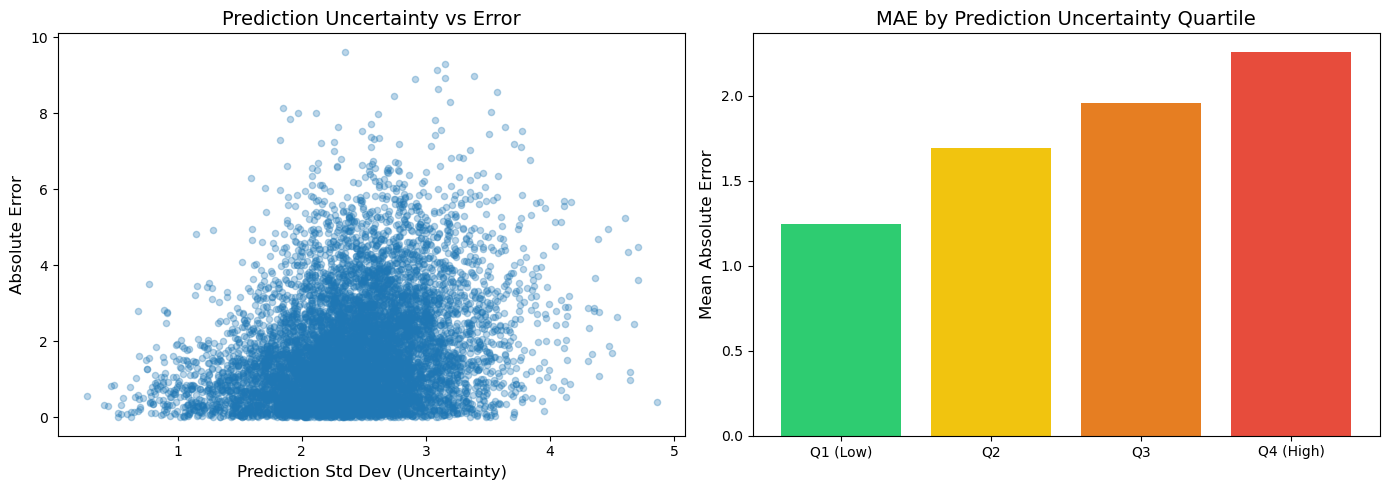

In [20]:
"""
====================================
Prediction Confidence Intervals
====================================
"""

print("### Prediction Confidence Analysis\n")

# For Random Forest, we can use the individual tree predictions
# to estimate prediction uncertainty

# Get predictions from individual trees
predictions = np.array([tree.predict(X_test) for tree in rf_best.estimators_])

# Calculate statistics
pred_mean = predictions.mean(axis=0)
pred_std = predictions.std(axis=0)

# Correlation between prediction std and absolute error
abs_errors = np.abs(y_test - pred_mean)
correlation = np.corrcoef(pred_std, abs_errors)[0, 1]

print(f"Correlation between prediction std and absolute error: {correlation:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction std vs absolute error
ax = axes[0]
ax.scatter(pred_std, abs_errors, alpha=0.3, s=20)
ax.set_xlabel('Prediction Std Dev (Uncertainty)', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Prediction Uncertainty vs Error', fontsize=14)

# Error by uncertainty quartile
ax = axes[1]
quartiles = pd.qcut(pred_std, 4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
uncertainty_analysis = pd.DataFrame({
    'quartile': quartiles,
    'abs_error': abs_errors
}).groupby('quartile')['abs_error'].mean()

ax.bar(range(4), uncertainty_analysis.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
ax.set_xticks(range(4))
ax.set_xticklabels(uncertainty_analysis.index)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.set_title('MAE by Prediction Uncertainty Quartile', fontsize=14)

plt.tight_layout()
plt.savefig('../images/05_predictive_modelling/prediction_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving Models

In [21]:
"""
====================================
Save Models
====================================
"""

import joblib

os.makedirs('../models', exist_ok=True)

# Save models
joblib.dump(lr, '../models/linear_regression.pkl')
joblib.dump(ridge, '../models/ridge_regression.pkl')
joblib.dump(lasso, '../models/lasso_regression.pkl')
joblib.dump(rf_best, '../models/random_forest_tuned.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

# Save feature names
with open('../models/feature_names.txt', 'w') as f:
    for feat in X.columns:
        f.write(f"{feat}\n")

print("Models saved to ../models/")
print("  - linear_regression.pkl")
print("  - ridge_regression.pkl")
print("  - lasso_regression.pkl")
print("  - random_forest_tuned.pkl")
print("  - feature_scaler.pkl")

Models saved to ../models/
  - linear_regression.pkl
  - ridge_regression.pkl
  - lasso_regression.pkl
  - random_forest_tuned.pkl
  - feature_scaler.pkl


# Conclusion

In [22]:
"""
====================================
Final Summary
====================================
"""

print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

summary = f"""
### Model Performance Summary

| Model | MAE | RMSE | R² | Within ±1 | Within ±2 | Exact V | Within ±1 V |
|-------|-----|------|----|-----------|-----------|---------|-------------|
| Linear Regression | {results_lr_test['mae']:.3f} | {results_lr_test['rmse']:.3f} | {results_lr_test['r2']:.3f} | {results_lr_test['within_1']:.1f}% | {results_lr_test['within_2']:.1f}% | {results_lr_test['exact_grouped_v']:.1f}% | {results_lr_test['within_1_vgrade']:.1f}% |
| Ridge Regression | {results_ridge['mae']:.3f} | {results_ridge['rmse']:.3f} | {results_ridge['r2']:.3f} | {results_ridge['within_1']:.1f}% | {results_ridge['within_2']:.1f}% | {results_ridge['exact_grouped_v']:.1f}% | {results_ridge['within_1_vgrade']:.1f}% |
| Lasso Regression | {results_lasso['mae']:.3f} | {results_lasso['rmse']:.3f} | {results_lasso['r2']:.3f} | {results_lasso['within_1']:.1f}% | {results_lasso['within_2']:.1f}% | {results_lasso['exact_grouped_v']:.1f}% | {results_lasso['within_1_vgrade']:.1f}% |
| Random Forest (Tuned) | {results_rf_tuned['mae']:.3f} | {results_rf_tuned['rmse']:.3f} | {results_rf_tuned['r2']:.3f} | {results_rf_tuned['within_1']:.1f}% | {results_rf_tuned['within_2']:.1f}% | {results_rf_tuned['exact_grouped_v']:.1f}% | {results_rf_tuned['within_1_vgrade']:.1f}% |

### Key Findings

1. **Tree-based models remain strongest on this structured feature set.**
   - Random Forest (Tuned) achieves the best overall balance of MAE, RMSE, and grouped V-grade performance.
   - Linear models remain useful baselines but leave clear nonlinear signal unexplained.

2. **Fine-grained difficulty prediction is meaningfully harder than grouped grade prediction.**
   - On the held-out test set, the best model is within ±1 fine-grained difficulty score {results_rf_tuned['within_1']:.1f}% of the time.
   - The same model is within ±1 grouped V-grade {results_rf_tuned['within_1_vgrade']:.1f}% of the time.

3. **This gap is expected and informative.**
   - Small numeric errors often stay inside the same or adjacent V-grade buckets.
   - The model captures broad difficulty bands more reliably than exact score distinctions.

4. **The project’s main predictive takeaway is practical rather than perfect.**
   - The models are not exact grade replicators.
   - They are reasonably strong at placing climbs into the correct neighborhood of difficulty.

### Portfolio Interpretation

From a modelling perspective, this project shows:
- feature engineering grounded in domain structure,
- comparison of linear and nonlinear models,
- honest evaluation on a held-out test set,
- and the ability to translate raw regression performance into climbing-relevant grouped V-grade metrics.
"""

print(summary)

# Save summary
os.makedirs('../data/05_predictive_modelling', exist_ok=True)
with open('../data/05_predictive_modelling/model_summary.txt', 'w') as f:
    f.write(summary)

print("\nSummary saved to ../data/05_predictive_modelling/model_summary.txt")


FINAL SUMMARY

### Model Performance Summary

| Model | MAE | RMSE | R² | Within ±1 | Within ±2 | Exact V | Within ±1 V |
|-------|-----|------|----|-----------|-----------|---------|-------------|
| Linear Regression | 2.191 | 2.742 | 0.537 | 28.1% | 53.1% | 23.9% | 61.3% |
| Ridge Regression | 2.191 | 2.742 | 0.537 | 28.1% | 53.1% | 23.9% | 61.3% |
| Lasso Regression | 2.192 | 2.741 | 0.538 | 27.9% | 53.1% | 23.8% | 61.3% |
| Random Forest (Tuned) | 1.788 | 2.293 | 0.676 | 36.1% | 64.3% | 30.2% | 70.8% |

### Key Findings

1. **Tree-based models remain strongest on this structured feature set.**
   - Random Forest (Tuned) achieves the best overall balance of MAE, RMSE, and grouped V-grade performance.
   - Linear models remain useful baselines but leave clear nonlinear signal unexplained.

2. **Fine-grained difficulty prediction is meaningfully harder than grouped grade prediction.**
   - On the held-out test set, the best model is within ±1 fine-grained difficulty score 36.1% of the

GRADIENT BOOSTING
### Gradient Boosting Evaluation

MAE:  1.869
RMSE: 2.354
R²:   0.659

Accuracy within ±1 grade: 33.8%
Accuracy within ±2 grades: 60.7%

Exact grouped V-grade accuracy: 28.2%
Accuracy within ±1 V-grade: 68.2%
Accuracy within ±2 V-grades: 89.2%


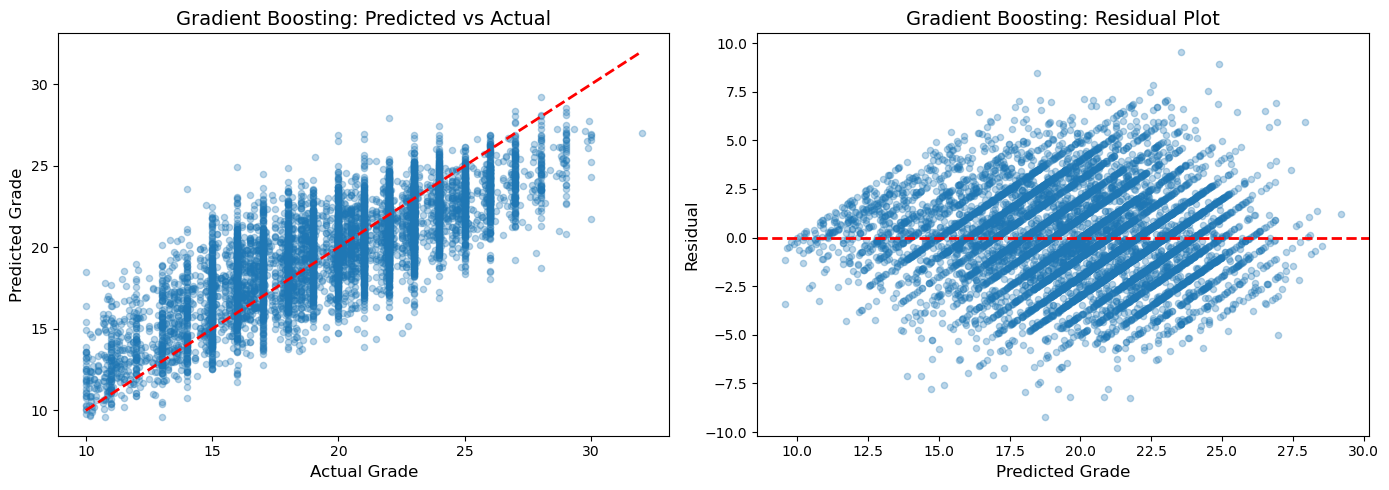

In [23]:
"""
====================================
Bonus: Gradient Boosting Comparison
====================================
"""

print("=" * 60)
print("GRADIENT BOOSTING")
print("=" * 60)

from sklearn.ensemble import GradientBoostingRegressor

# Train gradient boosting
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=5,
    random_state=RANDOM_STATE
)

gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Evaluate
results_gb = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
all_results.append({**results_gb, 'set': 'test'})

# Compare with Random Forest
plot_predictions(y_test, y_pred_gb, "Gradient Boosting")